# California Wildfires

![Smokey](images/smokey.jpg)

* Predict the size in acres of California wildfires using data from 2001 to 2018 (due to data availability)

## Goal

* Discover drivers of wildfire size
* Use drivers to develop a machine learning model to predict wildfire size
* This can hopefully be used to better prepare people for evacuation or farmers for some early harvesting (protect the vineyards)

## Imports

In [1]:
# local imports
import wrangle as w
import explore as e
import modeling as m

## Acquire

* Data acquired from Google BigQuery (EPA and USFS) and USDA
* Data initially acquired on 5 June 2023
* Dataset shapes before cleaning:
    * EPA: 32,888,162 rows, 29 columns
    * USFS: 22,985,028 rows, 348 columns
    * USDA: 2,303,566 rows, 39 columns
* Prebuilt dataset shape (already cleaned): 49243 rows, 25 columns
* Each row (after merge) represents a unique wildfire in California from 2001 to 2018 with averaged air quality data and most common tree species with averaged characteristics for the county the fire is located in
* Each column represents an element of the fire, tree species, or air quality

## Prepare

**Prepare Actions**:

* Renamed columns to promote readability and merging
* Removed columns
    - too many null values
    - related to target (fire_size_class)
    - duplicated information
    - too complex to explore for now
* Removed nulls
* Checked that column data types were appropriate
* Outliers were not handles in this iteration
* Created custom features
* Encoded categorical variables
* Split data into train, validate and test (approx. 60/20/20)
* Scaled using Standard Scaler for modeling

In [2]:
# acquire, clean, and prepare the data
df = w.wrangle_wildfires()

# encode categorical columns
df = w.encode(df)

# split into train, validate, and test datasets
train, val, test = w.split_data(df)

#### A brief look at the data

In [3]:
train.head()

,date,time,cause_class,cause,fire_size,fire_size_class,lat,long,elevation_mean,county,...,most_common_species_group_incense-cedar,most_common_species_group_lodgepole pine,most_common_species_group_oak,most_common_species_group_other western hardwoods,most_common_species_group_other western softwoods,most_common_species_group_ponderosa and jeffrey pines,most_common_species_group_redwood,most_common_species_group_true fir,most_common_species_group_woodland hardwoods,most_common_species_group_woodland softwoods
489,2001-08-12,915,human,recreation and ceremony,0.10,a,32.647281,-116.648461,4185.714286,san diego county,...,0,0,1,0,0,0,0,0,0,0
26116,2009-07-19,2058,human,missing data/not specified/undetermined,0.25,a,34.243611,-117.249722,6461.632653,san bernardino county,...,0,0,1,0,0,0,0,0,0,0
16562,2006-09-23,1739,human,missing data/not specified/undetermined,0.10,a,32.692903,-117.110944,4744.705882,san diego county,...,0,0,1,0,0,0,0,0,0,0
14518,2006-06-30,1501,human,missing data/not specified/undetermined,0.50,b,33.778056,-117.458889,557.142857,riverside county,...,0,0,0,0,0,0,0,0,1,0
33725,2011-08-15,1338,human,equipment and vehicle use,0.20,a,33.757497,-117.254080,5004.347826,riverside county,...,0,0,1,0,0,0,0,0,0,0


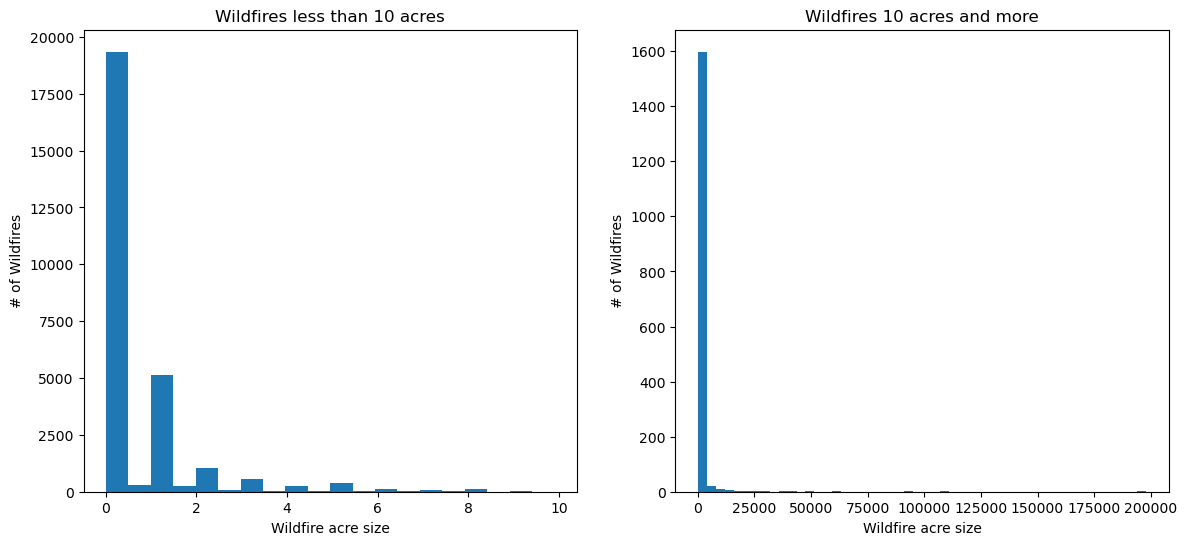

In [4]:
# quick dist
e.dist(train)

## Explore

* Is there a correlation between wind direction and fire size?
* Is there a correlation between time of day and fire size?
* Is there a correlation between relative humidity and fire size?
* Is there a correlation between outdoor temperature and fire size?
* Is there a correlation between percentage of living trees and fire size?

### 1) Is there a correlation between wind direction and fire size?
* $H_0$: There is **NO** correlation between wind direction and fire size
* $H_a$: There is a correlation between wind direction and fire size
* Continuous (wind_direction_mean) vs Continuous (fire_size) = $Spearman's R$
    - $r$ = 0.026817781273372275
    - $p$ = 4.021829936298224e-06
* `Wind direction` is correlated with `fire size`

Spearman's R: wind_direction_mean and fire_size
 r = 0.026817781273372275, p = 4.021829936298224e-06


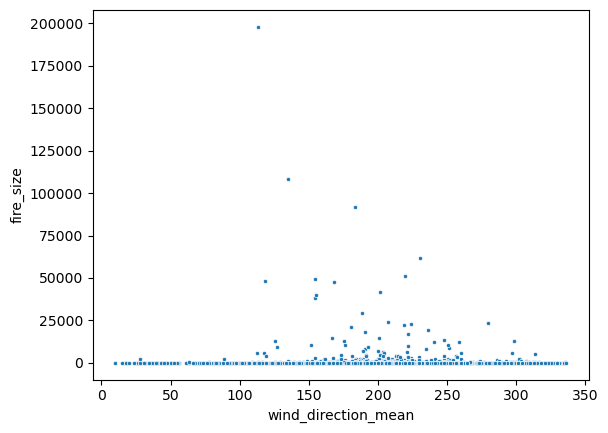

In [5]:
# explore wind direction and fire size
e.wind_dir(train)

**With an alpha of 0.05 (confidence 95%) the p-value is less than alpha. Therefore, evidence suggests that wind direction and fire size are correlated with each other. I believe that using `wind_direction_mean` in the modeling could have a positive impact.**

### 2) Is there a correlation between time of day and fire size?
* $H_0$: There is **NO** correlation between time of day and fire size
* $H_a$: There is a correlation between time of day and fire size
* Continuous (time) vs Continuous (fire_size) = $Spearman's R$
    - $r$ = -0.021152833940573768
    - $p$ = 0.00027675238141595883
* `Time of day` is negatively correlated with `fire size`

Spearman's R: time and fire_size
 r = -0.021152833940573768, p = 0.00027675238141595883


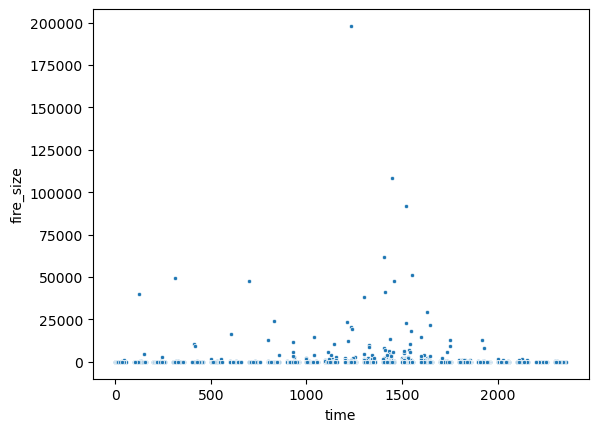

In [6]:
# explore time and fire size
e.time(train)

**With an alpha of 0.05 (confidence 95%) the p-value is less than alpha. Therefore, evidence suggests that time of day and fire size are negatively correlated with each other. I believe that using `time` in the modeling could have a positive impact.**

### 3) Is there a correlation between relative humidity and fire size?
* $H_0$: There is **NO** correlation between relative humidity and fire size
* $H_a$: There is a correlation between relative humidity and fire size
* Continuous (humidity_mean) vs Continuous (fire_size) = $Spearman's R$
    - $r$ = -0.022250971125873584
    - $p$ = 0.000130795840155992
* `Relative humidity` is negatively correlated with `fire size`

Spearman's R: humidity_mean and fire_size
 r = -0.022250971125873584, p = 0.000130795840155992


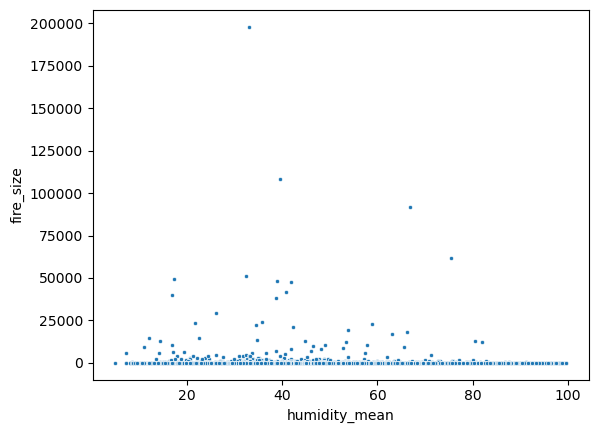

In [7]:
# explore relative humidity and fire size
e.humid(train)

**With an alpha of 0.05 (confidence 95%) the p-value is less than alpha. Therefore, evidence suggests that relative humidity and fire size are negatively correlated with each other. I believe that using `humidity_mean` in the modeling could have a positive impact.**

### 4) Is there a correlation between outdoor temperature and fire size?
* $H_0$: There is **NO** correlation between outdoor temperature and fire size
* $H_a$: There is a correlation between outdoor temperature and fire size
* Continuous (temp_mean) vs Continuous (fire_size) = $Spearman's R$
    - $r$ = 0.08441580301040426
    - $p$ = 7.241739059330505e-48
* `Outdoor temperature` is correlated with `fire size`

Spearman's R: temp_mean and fire_size
 r = 0.08441580301040426, p = 7.241739059330505e-48


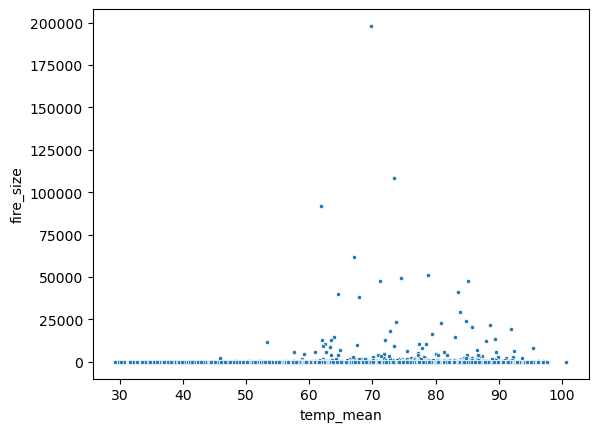

In [8]:
# explore outdoor temp and fire size
e.temp(train)

**With an alpha of 0.05 (confidence 95%) the p-value is less than alpha. Therefore, evidence suggests that outdoor temperature and fire size are correlated with each other. I believe that using `temp_mean` in the modeling could have a positive impact.**

### 5) Is there a correlation between percentage of living trees and fire size?
* $H_0$: There is **NO** correlation between percentage of living trees and fire size
* $H_a$: There is a correlation between percentage of living trees and fire size
* Continuous (percent_trees_alive) vs Continuous (fire_size) = $Spearman's R$
    - $r$ = 0.02029199601213557
    - $p$ = 0.0004864050513681311
* `Percentage of living trees` is correlated with `fire size`

Spearman's R: percent_trees_alive and fire_size
 r = 0.02029199601213557, p = 0.0004864050513681311


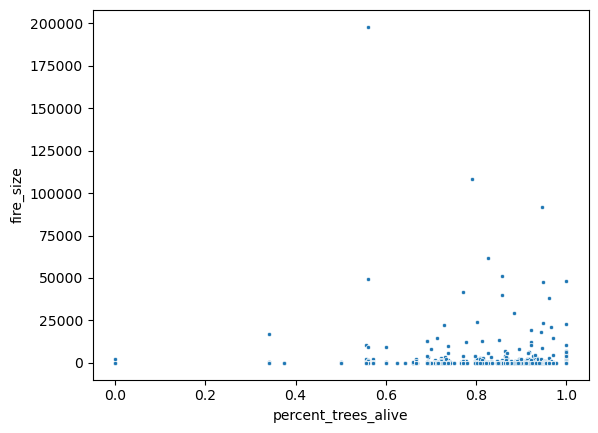

In [9]:
# explore percentage of living trees and fire size
e.alive(train)

**With an alpha of 0.05 (confidence 95%) the p-value is less than alpha. Therefore, evidence suggests that percentage of living trees and fire size are correlated with each other. I believe that using `percent_trees_alive` in the modeling could have a positive impact.**

## Exploration Summary
* Outdoor temperature is the most correlated of the these
* While outdoor temperature, wind direction, time of day, relative humidity, and percentage of living trees are correlated, the amount is still small and may help in modeling but probably not by much
* DIfferent sized wildfires are correlated with the features differently

### Features for modeling
* Features that will be used:
    - fire_size (target)
* Some features that may be useful:
    - wind_direction_mean
    - time
    - humidity_mean
    - temp_mean
    - percentage_trees_alive

## Modeling

* $RMSE$ and $R^2$ will be the evaluation metrics
* Target feature is fire_size
* Using the mean of the wildfire size as the baseline
    - 52.74 acres will be the baseline wildfire size
* Features scaled using Standard Scaler
* Models will be developed and evaluated using a few different model types, various features, and various hyperparameter configurations
    - Linear Regression
    - Polynomial Features through Linear Regression
    - Lasso Lars
* Models will be evaluated on train and validate datasets
* Best performing model will be the only one evaluated on the test dataset

In [10]:
# split into X and y
X_train,X_val,X_test = train.drop(columns=['fire_size','fire_size_class','date']),val.drop(columns=['fire_size','fire_size_class','date']),test.drop(columns=['fire_size','fire_size_class','date'])
y_train,y_val,y_test = train[['fire_size']],val[['fire_size']],test[['fire_size']]

# Standard Scaler
Xs_train,Xs_val,Xs_test = w.std(X_train,X_val,X_test,X_train.select_dtypes(exclude='object').columns)

In [11]:
# get baseline accuracy
m.baseline(y_train,y_val)

Baseline Fire Size: 52.74
Train       RMSE: 1695.8139670726937   R2: 0.0
Validate    RMSE: 1784.6010948249175    R2: -1.467037125113535e-07


### Best of 3 Model Configurations

#### Linear Regression

In [ ]:
# get linear regression results
m.final_model('lr',Xs_train,y_train,Xs_val,y_val)

#### Polynomial Features through Linear Regression

In [ ]:
# get polynomial feature results
m.final_model('poly',Xs_train,y_train,Xs_val,y_val)

#### Lasso Lars

In [ ]:
# get lasso lars results
m.final_model('lasso',Xs_train,y_train,Xs_val,y_val)

### Best on Test
* Polynomial Features

In [ ]:
# get test results for final model
m.test_model(Xs_train,y_train,Xs_test,y_test)

#### How does it compare?

In [ ]:
# plot predictions vs actual of test
m.plt_err(Xs_train,y_train,Xs_test,y_test)

### Modeling Wrap Up
* Waiting to model

## Conclusion

### Takeaways and Key Findings
* Outdoor temperature is the most correlated of the these
* While outdoor temperature, wind direction, time of day, relative humidity, and percentage of living trees are correlated, the amount is still small and may help in modeling but probably not by much
* DIfferent sized wildfires are correlated with the features differently
* Model still needs improvement

### Recommendations and Next Steps
* I would suggest...
* Given more time I would find a better way to more accurately merge the data, maybe even try some clustering techniques to find the 'hot zones' based on location